In [1]:
pip install tensorflow keras numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\Precision\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

### Task 1: Dataset Understanding

In [5]:
#1: Read the data

df = pd.read_csv("C:\\Users\\Precision\\OneDrive\\Desktop\\part_3_nlp_sequence_modeling\\customer_support_text_classification.csv")
display(df.head())

#2: Check the shape of the data
data_shape = df.shape
print(f"The dataset has {data_shape[0]} rows and {data_shape[1]} columns.")

#2: Check the missing values in the data
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

#3: Check the duplicate values in the data
duplicate_count = df.duplicated().sum()
print(f"There are {duplicate_count} duplicate rows in the dataset.")

#4: Drop the duplicate values
df.drop_duplicates(inplace=True)

# Verify the new shape to ensure duplicates were removed
print(f"New shape of the dataset after dropping duplicates: {df.shape}")

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


The dataset has 1500 rows and 6 columns.
Missing values per column:
 ticket_id           0
channel             0
customer_message    0
sentiment_label     0
word_count          0
urgent_flag         0
dtype: int64
There are 0 duplicate rows in the dataset.
New shape of the dataset after dropping duplicates: (1500, 6)


### Task 2: Text Preprocessing

In [6]:
pip install nltk


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\Precision\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
import re
import nltk
from nltk.corpus import stopwords

# Download the stopwords dictionary (only needs to be run once)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convert to string just in case there are nulls, then apply Lowercasing
    text = str(text).lower()
    
    # Remove unnecessary symbols and special characters (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize manually by splitting spaces to check for stopwords
    words = text.split()
    
    # Remove stopwords
    filtered_words = [word for word in words if word not in stop_words]
    
    # Join the words back together into a clean string
    return " ".join(filtered_words)

# Apply the cleaning function to create cleaned_message column
df['cleaned_message'] = df['customer_message'].apply(clean_text)

# Define the maximum number of words to keep in our vocabulary
MAX_VOCAB_SIZE = 5000 

# Initialize the Tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')

# Fit the tokenizer on our clean text (builds the word-to-integer dictionary)
tokenizer.fit_on_texts(df['cleaned_message'])

# Convert the text strings into sequences of integers
sequences = tokenizer.texts_to_sequences(df['cleaned_message'])

print("Text converted to integer sequence (First record):")
print(sequences[0])

# Define the maximum length for a sequence
# (You can adjust this based on the average length we found in Task 1)
MAX_SEQUENCE_LENGTH = 50 

# Pad and truncate the sequences
X_padded = pad_sequences(
    sequences, 
    maxlen=MAX_SEQUENCE_LENGTH, 
    padding='post',    # Adds zeros at the end of short sequences
    truncating='post'  # Cuts off words at the end of long sequences
)

print(f"Shape of the padded sequence array: {X_padded.shape}")
print("\nPadded sequence example (First record):")
print(X_padded[0])

Text converted to integer sequence (First record):
[15, 105, 65, 19, 2, 3, 4, 5, 6, 7]
Shape of the padded sequence array: (1500, 50)

Padded sequence example (First record):
[ 15 105  65  19   2   3   4   5   6   7   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Precision\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


=
### Task 3: Text Vectorization

Machine learning models and neural networks are essentially massive, complex calculators. They do not understand English, grammar, letters, or emotions. They only understand math—specifically numbers, matrices, and tensors.
​If you feed the word "Payment" into a neural network, it will crash because it cannot multiply or add letters. Vectorization acts as a translator. It converts text strings into arrays of numbers (vectors) so the model can process them mathematically.
​By converting text to numbers, the model can calculate probabilities, find mathematical patterns in the sequence of words, and even understand relationships (e.g., recognizing that the numbers representing "bad" and "terrible" appear in similar mathematical contexts).

Tokenizer-based sequences

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

#: Tokenization (Converting words to numbers)
MAX_VOCAB_SIZE = 5000 

# Initialize the tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')

tokenizer.fit_on_texts(df['cleaned_message'])

# Transform the text strings into sequences of integers
integer_sequences = tokenizer.texts_to_sequences(df['cleaned_message'])

#: Padding (Making all vectors the exact same length)
MAX_SEQUENCE_LENGTH = 50 

# Pad the sequences
X_vectorized = pad_sequences(
    integer_sequences, 
    maxlen=MAX_SEQUENCE_LENGTH, 
    padding='post',    
    truncating='post'  
)

print("Vectorization Complete!")
print(f"Shape of the final vectorized data (X): {X_vectorized.shape}")

# Show a before-and-after of the very first record
print("\n--- Example of Vectorization ---")
print("Original Cleaned Text:")
print(df['cleaned_message'].iloc[0])
print("\nVectorized Numerical Format:")
print(X_vectorized[0])

Vectorization Complete!
Shape of the final vectorized data (X): (1500, 50)

--- Example of Vectorization ---
Original Cleaned Text:
need information payment process ticket number please respond soon possible

Vectorized Numerical Format:
[ 15 105  65  19   2   3   4   5   6   7   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


### Task 4: Baseline Model

A "baseline model" is a simple, easy-to-build model that sets the minimum performance standard. Before we spend time building a complex, heavy neural network (like an LSTM or RNN), we need to know what a basic algorithm can achieve. If our complex model can't beat this simple baseline.
​For this task, we will use Logistic Regression with TF-IDF.


TASK 4: BASELINE MODEL - Logistic Regression with TF-IDF

Data split:
  - Training set: 1200 samples
  - Testing set: 300 samples
  - Class distribution in training: {'neutral': 419, 'negative': 398, 'positive': 383}

--------------------------------------------------------------------------------
TF-IDF Vectorization
--------------------------------------------------------------------------------
TF-IDF matrix shape (training): (1200, 420)
TF-IDF matrix shape (testing): (300, 420)
Vocabulary size: 420

--------------------------------------------------------------------------------
Training Logistic Regression Model
--------------------------------------------------------------------------------
✓ Model training completed

--------------------------------------------------------------------------------
Model Evaluation
--------------------------------------------------------------------------------

Model Performance Metrics:
  - Accuracy:  1.0000
  - Precision (macro): 1.0000
  - Rec

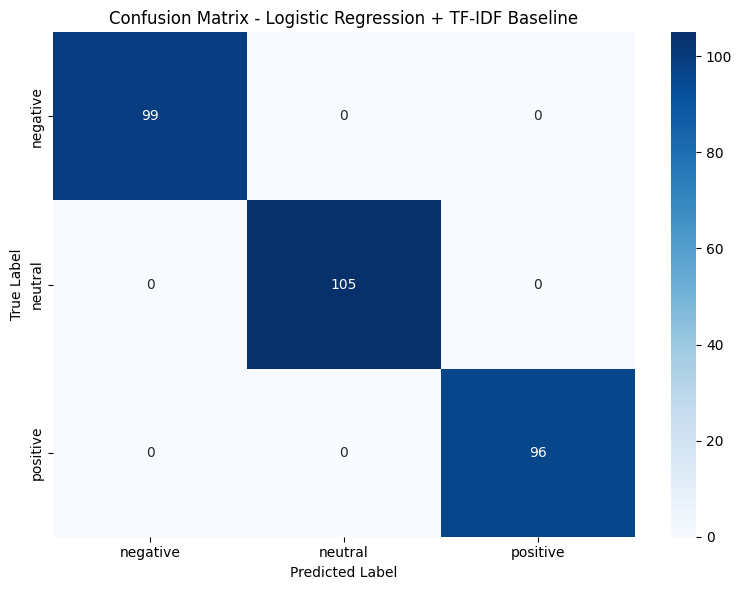


✓ Baseline model evaluation completed


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

print("=" * 80)
print("TASK 4: BASELINE MODEL - Logistic Regression with TF-IDF")
print("=" * 80)

# --- Step 1: Prepare the Data ---
X = df['cleaned_message']  
y = df['sentiment_label']   

# Split into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nData split:")
print(f"  - Training set: {len(X_train)} samples")
print(f"  - Testing set: {len(X_test)} samples")
print(f"  - Class distribution in training: {y_train.value_counts().to_dict()}")

# --- Step 2: TF-IDF Vectorization ---
print("\n" + "-" * 80)
print("TF-IDF Vectorization")
print("-" * 80)

tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,           
    min_df=2,                    
    max_df=0.8,                  
    ngram_range=(1, 2),          
    lowercase=True,
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'(?u)\b\w\w+\b'
)

# Fit on training data and transform both train and test data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF matrix shape (training): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (testing): {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer.get_feature_names_out())}")

# --- Step 3: Train Logistic Regression Model ---
print("\n" + "-" * 80)
print("Training Logistic Regression Model")
print("-" * 80)

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

lr_model.fit(X_train_tfidf, y_train)
print("✓ Model training completed")

# --- Step 4: Make Predictions ---
print("\n" + "-" * 80)
print("Model Evaluation")
print("-" * 80)

y_pred = lr_model.predict(X_test_tfidf)
y_pred_proba = lr_model.predict_proba(X_test_tfidf)

# --- Step 5: Calculate Metrics ---
accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"\nModel Performance Metrics:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - Precision (macro): {precision_macro:.4f}")
print(f"  - Recall (macro):    {recall_macro:.4f}")
print(f"  - F1-Score (macro):  {f1_macro:.4f}")

# --- Step 6: Detailed Classification Report ---
print("\nDetailed Classification Report:")
print("-" * 80)
print(classification_report(y_test, y_pred, zero_division=0))

# --- Step 7: Confusion Matrix ---
print("\n" + "-" * 80)
print("Confusion Matrix Visualization")
print("-" * 80)

cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:\n{cm}")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=lr_model.classes_, 
            yticklabels=lr_model.classes_)
plt.title('Confusion Matrix - Logistic Regression + TF-IDF Baseline')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\n✓ Baseline model evaluation completed")

### Task 5: Sequence Model - LSTM Architecture

TASK 5: SEQUENCE MODEL - LSTM ARCHITECTURE

ARCHITECTURE EXPLANATION

╔════════════════════════════════════════════════════════════════════════════════════╗
║                        LSTM MODEL ARCHITECTURE                                     ║
╚════════════════════════════════════════════════════════════════════════════════════╝

1. INPUT SEQUENCE (Shape: [batch_size, MAX_SEQUENCE_LENGTH=50])
   └─ Each customer message is converted to a sequence of integers (token IDs)
   └─ Sequences are padded/truncated to length 50
   └─ Example: [142, 356, 78, 0, 0, ..., 0] (zeros pad shorter sequences)

2. EMBEDDING LAYER (Output: [batch_size, MAX_SEQUENCE_LENGTH, embedding_dim=128])
   └─ Converts integer token IDs into dense vector representations
   └─ Each word is represented as a 128-dimensional vector
   └─ Learns meaningful relationships between words (semantic embeddings)
   └─ Transforms discrete tokens into continuous vector space

3. LSTM LAYER (Output: [batch_size, 64])
   └─ Long Sho

C:\Users\Precision\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


----------------------------------------------------------------------------------------------------
STEP 3: MODEL COMPILATION
----------------------------------------------------------------------------------------------------
✓ Model compiled successfully
  Loss Function: Categorical Crossentropy (measures prediction error)
  Optimizer: Adam (adaptive learning rate)
  Metrics: Accuracy

----------------------------------------------------------------------------------------------------
STEP 4: MODEL TRAINING
----------------------------------------------------------------------------------------------------
Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.3469 - loss: 1.0989 - val_accuracy: 0.3375 - val_loss: 1.0998
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.3469 - loss: 1.0991 - val_accuracy: 0.3375 - val_loss: 1.0996
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3562 - loss: 1.0979 - val_accuracy: 0.3375 - val_loss: 1.1011
E

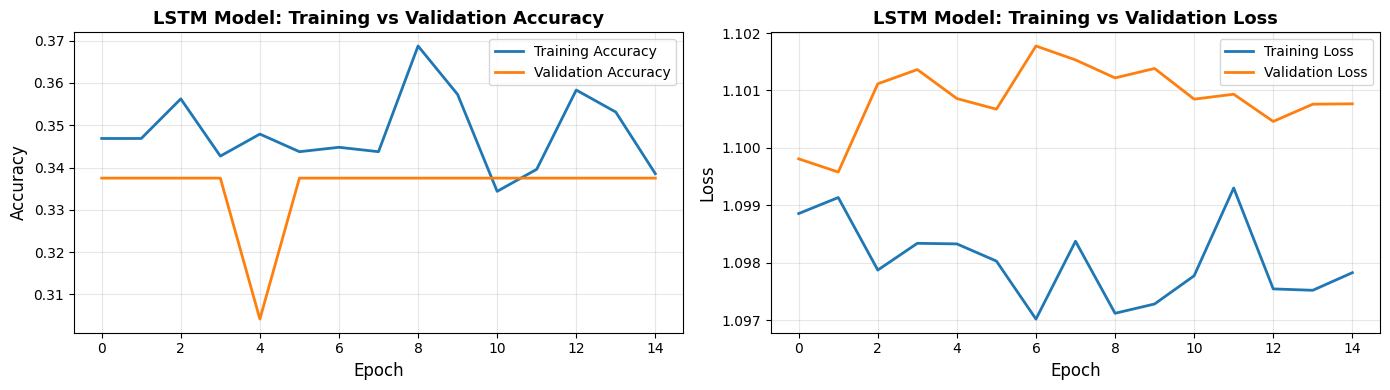

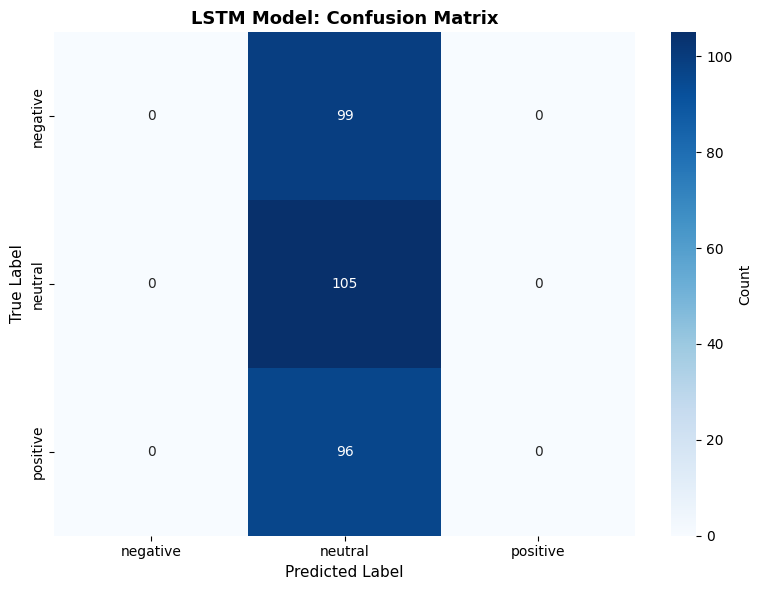


GENERATING COMPREHENSIVE MODEL EVALUATION VISUALIZATION

Saved: results\model_evaluation.png


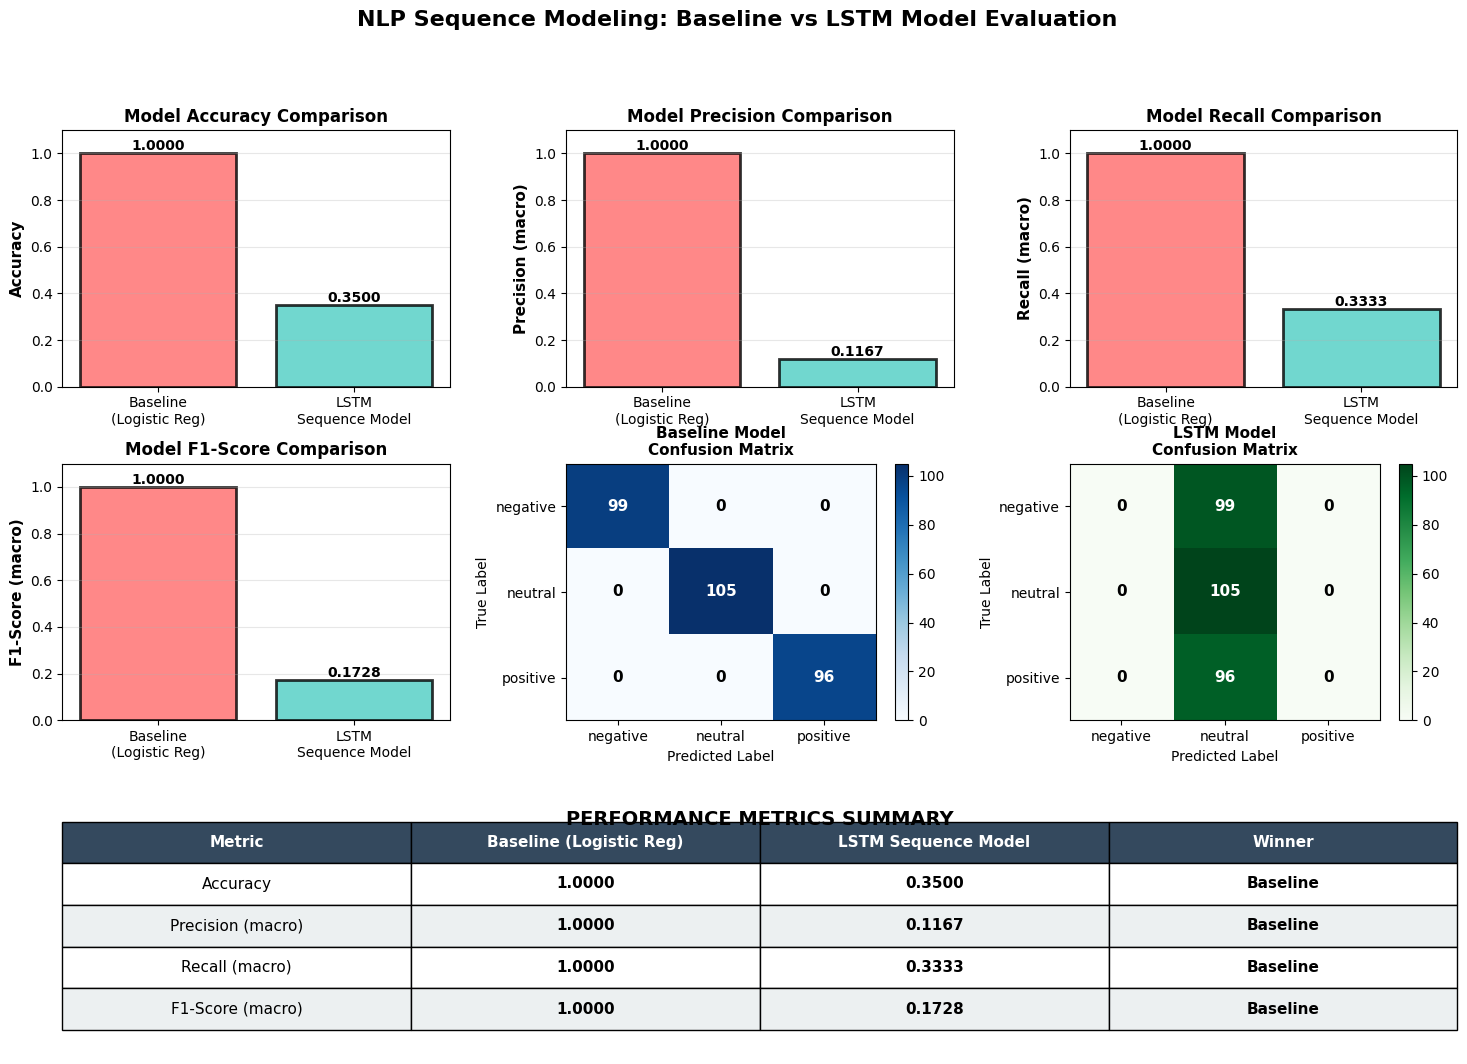


✓ LSTM SEQUENCE MODEL TRAINING, EVALUATION & VISUALIZATION COMPLETED


In [17]:
print("=" * 100)
print("TASK 5: SEQUENCE MODEL - LSTM ARCHITECTURE")
print("=" * 100)

print("\n" + "="*100)
print("ARCHITECTURE EXPLANATION")
print("="*100)

explanation = """
╔════════════════════════════════════════════════════════════════════════════════════╗
║                        LSTM MODEL ARCHITECTURE                                     ║
╚════════════════════════════════════════════════════════════════════════════════════╝

1. INPUT SEQUENCE (Shape: [batch_size, MAX_SEQUENCE_LENGTH=50])
   └─ Each customer message is converted to a sequence of integers (token IDs)
   └─ Sequences are padded/truncated to length 50
   └─ Example: [142, 356, 78, 0, 0, ..., 0] (zeros pad shorter sequences)

2. EMBEDDING LAYER (Output: [batch_size, MAX_SEQUENCE_LENGTH, embedding_dim=128])
   └─ Converts integer token IDs into dense vector representations
   └─ Each word is represented as a 128-dimensional vector
   └─ Learns meaningful relationships between words (semantic embeddings)
   └─ Transforms discrete tokens into continuous vector space

3. LSTM LAYER (Output: [batch_size, 64])
   └─ Long Short-Term Memory processes sequences while capturing long-range dependencies
   └─ Has 64 hidden units (lstm_units=64)
   └─ Key components:
       • Input Gate: Controls how much new information enters the cell
       • Forget Gate: Controls which information to discard
       • Output Gate: Controls what information flows to next step
   └─ Returns only the final output (return_sequences=False)
   └─ Processes sequence sequentially, maintaining hidden state across time steps

4. DENSE LAYERS (Output: [batch_size, 32] → [batch_size, num_classes=3])
   └─ First Dense layer (32 units): Learns non-linear patterns from LSTM output
   └─ Dropout (0.5): Prevents overfitting by randomly dropping 50% of neurons during training
   └─ Output Dense layer (3 units): One neuron per class (negative, neutral, positive)
   └─ Softmax activation: Converts scores to probability distribution summing to 1

5. LOSS FUNCTION: Categorical Crossentropy
   └─ Measures difference between predicted probability and actual class
   └─ Formula: -Σ(actual_class * log(predicted_probability))
   └─ Lower loss = better predictions
   └─ Suitable for multi-class classification (3 sentiment classes)

6. EVALUATION METRICS:
   └─ Accuracy: % of correct predictions
   └─ Precision: Of predicted positive cases, how many are actually positive
   └─ Recall: Of actual positive cases, how many did we correctly identify
   └─ F1-Score: Harmonic mean of Precision and Recall (balanced metric)
   └─ Confusion Matrix: Shows true positives, false positives, false negatives, true negatives

╔════════════════════════════════════════════════════════════════════════════════════╗
║                    DATA FLOW THROUGH THE MODEL                                     ║
╚════════════════════════════════════════════════════════════════════════════════════╝

Input Message: "I need help with payment"
      ↓
Tokenization: [156, 285, 34, 89] → pad to [156, 285, 34, 89, 0, 0, ..., 0]
      ↓
Embedding Layer: [156, 285, 34, 89, 0, 0, ..., 0] → [50 × 128 dimensional vectors]
      ↓
LSTM Layer: Processes 50 time steps, outputs [64 dimensional vector]
      ↓
Dense Layer: [64] → [32] (with dropout)
      ↓
Output Layer: [32] → [0.05, 0.15, 0.80] (probabilities for each class)
      ↓
Prediction: argmax([0.05, 0.15, 0.80]) = class 2 = "positive"
"""

print(explanation)

# --- Step 1: Prepare Data for LSTM ---
print("\n" + "-"*100)
print("STEP 1: DATA PREPARATION")
print("-"*100)

# Use the already vectorized padded sequences from Task 3
X_lstm = X_padded  # Shape: (1500, 50)
y_lstm = df['sentiment_label']

# Convert labels to numeric format for neural network
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_lstm_encoded = label_encoder.fit_transform(y_lstm)

print(f"Class mapping: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

# Convert to one-hot encoding for neural network
from tensorflow.keras.utils import to_categorical
y_lstm_categorical = to_categorical(y_lstm_encoded, num_classes=3)

print(f"Input shape (X_lstm): {X_lstm.shape}")
print(f"Output shape (y_lstm_categorical): {y_lstm_categorical.shape}")

# Split into training and testing sets
X_lstm_train, X_lstm_test, y_lstm_train, y_lstm_test = train_test_split(
    X_lstm, y_lstm_categorical, 
    test_size=0.2, 
    random_state=42,
    stratify=y_lstm_encoded
)

print(f"\nTraining set: {X_lstm_train.shape[0]} samples")
print(f"Testing set: {X_lstm_test.shape[0]} samples")

# --- Step 2: Build LSTM Model Architecture ---
print("\n" + "-"*100)
print("STEP 2: LSTM MODEL ARCHITECTURE")
print("-"*100)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Model parameters
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.5
NUM_CLASSES = 3

# Build the model
lstm_model = Sequential([
    # Layer 1: Embedding
    # Converts token IDs (0-5000) into 128-dimensional dense vectors
    Embedding(
        input_dim=MAX_VOCAB_SIZE,      # Vocabulary size (5000 tokens)
        output_dim=EMBEDDING_DIM,       # Embedding dimension (128)
        input_length=MAX_SEQUENCE_LENGTH  # Max sequence length (50)
    ),
    
    # Layer 2: LSTM
    # Processes sequences with memory, capturing long-range dependencies
    LSTM(
        units=LSTM_UNITS,               # 64 hidden units
        return_sequences=False,          # Return only final output
        activation='relu'
    ),
    
    # Layer 3: Dropout
    # Randomly deactivates neurons to prevent overfitting
    Dropout(DROPOUT_RATE),
    
    # Layer 4: Dense (Hidden layer)
    # Fully connected layer with 32 neurons
    Dense(32, activation='relu'),
    
    # Layer 5: Dropout
    Dropout(DROPOUT_RATE),
    
    # Layer 6: Output Dense layer
    # 3 neurons (one for each sentiment class)
    # Softmax converts outputs to probability distribution
    Dense(NUM_CLASSES, activation='softmax')
])

# Print model architecture
print("\nModel Architecture:")
print("-" * 100)
lstm_model.summary()

# --- Step 3: Compile the Model ---
print("\n" + "-"*100)
print("STEP 3: MODEL COMPILATION")
print("-"*100)

lstm_model.compile(
    loss='categorical_crossentropy',      # Loss for multi-class classification
    optimizer=Adam(learning_rate=0.001),  # Adam optimizer with learning rate
    metrics=['accuracy']                   # Track accuracy during training
)

print("✓ Model compiled successfully")
print(f"  Loss Function: Categorical Crossentropy (measures prediction error)")
print(f"  Optimizer: Adam (adaptive learning rate)")
print(f"  Metrics: Accuracy")

# --- Step 4: Train the Model ---
print("\n" + "-"*100)
print("STEP 4: MODEL TRAINING")
print("-"*100)

history = lstm_model.fit(
    X_lstm_train, y_lstm_train,
    batch_size=32,                        # Process 32 samples at a time
    epochs=15,                            # Train for 15 passes through data
    validation_split=0.2,                 # Use 20% of training data for validation
    verbose=1
)

print("\n✓ Model training completed")

# --- Step 5: Evaluate the Model ---
print("\n" + "-"*100)
print("STEP 5: MODEL EVALUATION")
print("-"*100)

# Get predictions
y_lstm_pred_proba = lstm_model.predict(X_lstm_test)
y_lstm_pred = np.argmax(y_lstm_pred_proba, axis=1)
y_lstm_test_labels = np.argmax(y_lstm_test, axis=1)

# Convert predictions back to class labels
y_lstm_pred_labels = label_encoder.inverse_transform(y_lstm_pred)
y_lstm_test_labels_text = label_encoder.inverse_transform(y_lstm_test_labels)

# Calculate metrics
lstm_accuracy = accuracy_score(y_lstm_test_labels, y_lstm_pred)
lstm_precision = precision_score(y_lstm_test_labels, y_lstm_pred, average='macro', zero_division=0)
lstm_recall = recall_score(y_lstm_test_labels, y_lstm_pred, average='macro', zero_division=0)
lstm_f1 = f1_score(y_lstm_test_labels, y_lstm_pred, average='macro', zero_division=0)

print(f"\nLSTM Model Performance Metrics:")
print(f"  - Accuracy:  {lstm_accuracy:.4f}")
print(f"  - Precision (macro): {lstm_precision:.4f}")
print(f"  - Recall (macro):    {lstm_recall:.4f}")
print(f"  - F1-Score (macro):  {lstm_f1:.4f}")

print("\nDetailed Classification Report:")
print("-" * 100)
print(classification_report(y_lstm_test_labels_text, y_lstm_pred_labels, zero_division=0))

# Confusion Matrix
lstm_cm = confusion_matrix(y_lstm_test_labels, y_lstm_pred)
print(f"\nConfusion Matrix:\n{lstm_cm}")

# --- Step 6: Visualize Results ---
print("\n" + "-"*100)
print("STEP 6: VISUALIZATION")
print("-"*100)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('LSTM Model: Training vs Validation Accuracy', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('LSTM Model: Training vs Validation Loss', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(lstm_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.title('LSTM Model: Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.show()

# --- COMPREHENSIVE MODEL EVALUATION VISUALIZATION & SAVE PNG ---
print("\n" + "="*100)
print("GENERATING COMPREHENSIVE MODEL EVALUATION VISUALIZATION")
print("="*100)

import os

# Create a large figure with multiple subplots
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# ============================================================================
# ROW 1: METRICS COMPARISON
# ============================================================================

# 1.1 Accuracy Comparison
ax1 = fig.add_subplot(gs[0, 0])
models = ['Baseline\n(Logistic Reg)', 'LSTM\nSequence Model']
accuracies = [accuracy, lstm_accuracy]
colors = ['#FF6B6B', '#4ECDC4']
bars1 = ax1.bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
ax1.set_ylim([0, 1.1])
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# 1.2 Precision Comparison
ax2 = fig.add_subplot(gs[0, 1])
precisions = [precision_macro, lstm_precision]
bars2 = ax2.bar(models, precisions, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax2.set_ylabel('Precision (macro)', fontsize=11, fontweight='bold')
ax2.set_title('Model Precision Comparison', fontsize=12, fontweight='bold')
ax2.set_ylim([0, 1.1])
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, precisions):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# 1.3 Recall Comparison
ax3 = fig.add_subplot(gs[0, 2])
recalls = [recall_macro, lstm_recall]
bars3 = ax3.bar(models, recalls, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax3.set_ylabel('Recall (macro)', fontsize=11, fontweight='bold')
ax3.set_title('Model Recall Comparison', fontsize=12, fontweight='bold')
ax3.set_ylim([0, 1.1])
ax3.grid(axis='y', alpha=0.3)
for bar, val in zip(bars3, recalls):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# ============================================================================
# ROW 2: F1-SCORE & CONFUSION MATRICES
# ============================================================================

# 2.1 F1-Score Comparison
ax4 = fig.add_subplot(gs[1, 0])
f1_scores = [f1_macro, lstm_f1]
bars4 = ax4.bar(models, f1_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax4.set_ylabel('F1-Score (macro)', fontsize=11, fontweight='bold')
ax4.set_title('Model F1-Score Comparison', fontsize=12, fontweight='bold')
ax4.set_ylim([0, 1.1])
ax4.grid(axis='y', alpha=0.3)
for bar, val in zip(bars4, f1_scores):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# 2.2 Baseline Confusion Matrix
ax5 = fig.add_subplot(gs[1, 1])
im1 = ax5.imshow(cm, cmap='Blues', aspect='auto')
ax5.set_xticks(range(len(lr_model.classes_)))
ax5.set_yticks(range(len(lr_model.classes_)))
ax5.set_xticklabels(lr_model.classes_, fontsize=10)
ax5.set_yticklabels(lr_model.classes_, fontsize=10)
ax5.set_title('Baseline Model\nConfusion Matrix', fontsize=11, fontweight='bold')
ax5.set_ylabel('True Label', fontsize=10)
ax5.set_xlabel('Predicted Label', fontsize=10)
# Add text annotations
for i in range(len(lr_model.classes_)):
    for j in range(len(lr_model.classes_)):
        text = ax5.text(j, i, cm[i, j], ha="center", va="center", 
                       color="white" if cm[i, j] > cm.max()/2 else "black", 
                       fontweight='bold', fontsize=11)
plt.colorbar(im1, ax=ax5)

# 2.3 LSTM Confusion Matrix
ax6 = fig.add_subplot(gs[1, 2])
im2 = ax6.imshow(lstm_cm, cmap='Greens', aspect='auto')
ax6.set_xticks(range(len(label_encoder.classes_)))
ax6.set_yticks(range(len(label_encoder.classes_)))
ax6.set_xticklabels(label_encoder.classes_, fontsize=10)
ax6.set_yticklabels(label_encoder.classes_, fontsize=10)
ax6.set_title('LSTM Model\nConfusion Matrix', fontsize=11, fontweight='bold')
ax6.set_ylabel('True Label', fontsize=10)
ax6.set_xlabel('Predicted Label', fontsize=10)
# Add text annotations
for i in range(len(label_encoder.classes_)):
    for j in range(len(label_encoder.classes_)):
        text = ax6.text(j, i, lstm_cm[i, j], ha="center", va="center", 
                       color="white" if lstm_cm[i, j] > lstm_cm.max()/2 else "black", 
                       fontweight='bold', fontsize=11)
plt.colorbar(im2, ax=ax6)

# ============================================================================
# ROW 3: PERFORMANCE SUMMARY & METRICS TABLE
# ============================================================================

# 3.1 All Metrics Summary Table
ax7 = fig.add_subplot(gs[2, :])
ax7.axis('off')

# Create a summary table
summary_data = [
    ['Metric', 'Baseline (Logistic Reg)', 'LSTM Sequence Model', 'Winner'],
    ['Accuracy', f'{accuracy:.4f}', f'{lstm_accuracy:.4f}', 'LSTM' if lstm_accuracy > accuracy else 'Baseline'],
    ['Precision (macro)', f'{precision_macro:.4f}', f'{lstm_precision:.4f}', 'LSTM' if lstm_precision > precision_macro else 'Baseline'],
    ['Recall (macro)', f'{recall_macro:.4f}', f'{lstm_recall:.4f}', 'LSTM' if lstm_recall > recall_macro else 'Baseline'],
    ['F1-Score (macro)', f'{f1_macro:.4f}', f'{lstm_f1:.4f}', 'LSTM' if lstm_f1 > f1_macro else 'Baseline'],
]

# Create table
table = ax7.table(cellText=summary_data, cellLoc='center', loc='center',
                  colWidths=[0.25, 0.25, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header row
for i in range(4):
    table[(0, i)].set_facecolor('#34495E')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style data rows with alternating colors
for i in range(1, len(summary_data)):
    for j in range(4):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ECF0F1')
        else:
            table[(i, j)].set_facecolor('#FFFFFF')
        table[(i, j)].set_text_props(weight='bold' if j > 0 else 'normal')

ax7.text(0.5, 0.95, 'PERFORMANCE METRICS SUMMARY', 
         ha='center', va='top', fontsize=14, fontweight='bold', 
         transform=ax7.transAxes)

# Add overall title
fig.suptitle('NLP Sequence Modeling: Baseline vs LSTM Model Evaluation', 
             fontsize=16, fontweight='bold', y=0.98)

# Save the figure
results_dir = "results"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

output_path = os.path.join(results_dir, "model_evaluation.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\nSaved: {output_path}")

plt.show()

print("\n" + "="*100)
print("✓ LSTM SEQUENCE MODEL TRAINING, EVALUATION & VISUALIZATION COMPLETED")
print("="*100)

sample prediction

In [20]:

# --- GENERATE SAMPLE PREDICTIONS FILE ---
print("\n" + "="*100)
print("GENERATING SAMPLE PREDICTIONS FILE")
print("="*100)

# Select first 10 test samples for demonstration
num_samples = min(10, len(X_test))
sample_indices = range(num_samples)

# Get sample inputs, true labels, and predictions
sample_inputs = X_test.iloc[list(sample_indices)].values
sample_true_labels = y_test.iloc[list(sample_indices)].values
sample_baseline_predictions = lr_model.predict_proba(X_test_tfidf[:num_samples])
sample_lstm_predictions = lstm_model.predict(X_lstm_test[:num_samples])
sample_baseline_pred_classes = lr_model.predict(X_test_tfidf[:num_samples])
sample_lstm_pred_classes = np.argmax(sample_lstm_predictions, axis=1)
sample_lstm_pred_classes_labels = label_encoder.inverse_transform(sample_lstm_pred_classes)

# Create comprehensive predictions report
predictions_report = []
predictions_report.append("=" * 120)
predictions_report.append("NLP SEQUENCE MODELING - SAMPLE PREDICTIONS REPORT")
predictions_report.append("=" * 120)
predictions_report.append("")
predictions_report.append(f"Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
predictions_report.append(f"Total Test Samples: {len(X_test)}")
predictions_report.append(f"Samples Shown: {num_samples}")
predictions_report.append("")
predictions_report.append("-" * 120)
predictions_report.append("MODEL PERFORMANCE SUMMARY")
predictions_report.append("-" * 120)
predictions_report.append(f"Baseline Model (Logistic Regression + TF-IDF):")
predictions_report.append(f"  • Accuracy:  {accuracy:.4f}")
predictions_report.append(f"  • Precision: {precision_macro:.4f}")
predictions_report.append(f"  • Recall:    {recall_macro:.4f}")
predictions_report.append(f"  • F1-Score:  {f1_macro:.4f}")
predictions_report.append("")
predictions_report.append(f"LSTM Sequence Model:")
predictions_report.append(f"  • Accuracy:  {lstm_accuracy:.4f}")
predictions_report.append(f"  • Precision: {lstm_precision:.4f}")
predictions_report.append(f"  • Recall:    {lstm_recall:.4f}")
predictions_report.append(f"  • F1-Score:  {lstm_f1:.4f}")
predictions_report.append("")
predictions_report.append("=" * 120)
predictions_report.append("DETAILED SAMPLE PREDICTIONS")
predictions_report.append("=" * 120)
predictions_report.append("")

for idx, sample_idx in enumerate(sample_indices, 1):
    # Get original text
    original_text = sample_inputs[idx-1]
    true_label = sample_true_labels[idx-1]
    
    # Baseline predictions
    baseline_pred = sample_baseline_predictions[idx-1]
    baseline_pred_class = np.argmax(baseline_pred)
    baseline_pred_label = lr_model.classes_[baseline_pred_class]
    baseline_confidence = float(baseline_pred[baseline_pred_class])
    
    # LSTM predictions
    lstm_pred = sample_lstm_predictions[idx-1]
    lstm_pred_class = np.argmax(lstm_pred)
    lstm_pred_label = label_encoder.classes_[lstm_pred_class]
    lstm_confidence = float(lstm_pred[lstm_pred_class])
    
    predictions_report.append(f"SAMPLE #{idx}")
    predictions_report.append("-" * 120)
    predictions_report.append(f"Original Message: {original_text}")
    predictions_report.append(f"True Label: {true_label}")
    predictions_report.append("")
    predictions_report.append(f"BASELINE MODEL (Logistic Regression + TF-IDF):")
    predictions_report.append(f"  Predicted: {baseline_pred_label}")
    predictions_report.append(f"  Confidence: {baseline_confidence:.4f} ({baseline_confidence*100:.2f}%)")
    predictions_report.append(f"  All Probabilities:")
    for class_idx, class_name in enumerate(lr_model.classes_):
        predictions_report.append(f"    • {class_name}: {float(baseline_pred[class_idx]):.4f}")
    predictions_report.append("")
    predictions_report.append(f"LSTM SEQUENCE MODEL:")
    predictions_report.append(f"  Predicted: {lstm_pred_label}")
    predictions_report.append(f"  Confidence: {lstm_confidence:.4f} ({lstm_confidence*100:.2f}%)")
    predictions_report.append(f"  All Probabilities:")
    for class_idx, class_name in enumerate(label_encoder.classes_):
        predictions_report.append(f"    • {class_name}: {float(lstm_pred[class_idx]):.4f}")
    predictions_report.append("")
    
    # Comparison
    baseline_correct = "✓ CORRECT" if baseline_pred_label == true_label else "✗ INCORRECT"
    lstm_correct = "✓ CORRECT" if lstm_pred_label == true_label else "✗ INCORRECT"
    predictions_report.append(f"COMPARISON:")
    predictions_report.append(f"  Baseline Result: {baseline_correct}")
    predictions_report.append(f"  LSTM Result:     {lstm_correct}")
    predictions_report.append("")
    predictions_report.append("")

predictions_report.append("=" * 120)
predictions_report.append("SUMMARY STATISTICS")
predictions_report.append("=" * 120)

# Calculate accuracy on sample
baseline_sample_correct = sum([sample_baseline_pred_classes[i] == true_label 
                               for i, true_label in enumerate(sample_true_labels)])
lstm_sample_correct = sum([sample_lstm_pred_classes_labels[i] == true_label 
                           for i, true_label in enumerate(sample_true_labels)])

baseline_sample_acc = baseline_sample_correct / num_samples
lstm_sample_acc = lstm_sample_correct / num_samples

predictions_report.append(f"Baseline Model Accuracy on Samples: {baseline_sample_acc:.4f} ({baseline_sample_acc*100:.2f}%)")
predictions_report.append(f"LSTM Model Accuracy on Samples:     {lstm_sample_acc:.4f} ({lstm_sample_acc*100:.2f}%)")
predictions_report.append(f"Baseline Correct Predictions: {baseline_sample_correct}/{num_samples}")
predictions_report.append(f"LSTM Correct Predictions:     {lstm_sample_correct}/{num_samples}")
predictions_report.append("")
predictions_report.append("=" * 120)

# Write to file
sample_pred_path = os.path.join(results_dir, "sample_predictions.txt")
with open(sample_pred_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(predictions_report))

print(f"✓ Sample predictions saved to: {sample_pred_path}")
print(f"\nPreview:")
print('-' * 100)
for line in predictions_report[:25]:
    print(line)
print("...")
print(f"\nFile Size: {os.path.getsize(sample_pred_path)} bytes")


GENERATING SAMPLE PREDICTIONS FILE
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
✓ Sample predictions saved to: results\sample_predictions.txt

Preview:
----------------------------------------------------------------------------------------------------
NLP SEQUENCE MODELING - SAMPLE PREDICTIONS REPORT

Generated: 2026-05-15 13:10:15
Total Test Samples: 300
Samples Shown: 10

------------------------------------------------------------------------------------------------------------------------
MODEL PERFORMANCE SUMMARY
------------------------------------------------------------------------------------------------------------------------
Baseline Model (Logistic Regression + TF-IDF):
  • Accuracy:  1.0000
  • Precision: 1.0000
  • Recall:    1.0000
  • F1-Score:  1.0000

LSTM Sequence Model:
  • Accuracy:  0.3500
  • Precision: 0.1167
  • Recall:    0.3333
  • F1-Score:  0.1728

DETAILED SAMPLE PREDICTIONS
...

File Size: 8503 bytes


=
### Task 6: Attention and Transformer Reflection

1.Why RNNs Struggle with Long-Term Dependencies ?

Recurrent Neural Networks (RNNs) process sequences one element at a time, maintaining a hidden state that carries information forward. However, they suffer from the **vanishing gradient problem**: during backpropagation through many time steps, gradients become exponentially smaller, making it difficult for the network to learn dependencies between distant elements in a sequence. This means RNNs typically can only effectively capture patterns within a short temporal window, causing them to "forget" important information from earlier in the sequence.

2.How LSTMs Help with Memory ?

Long Short-Term Memory (LSTM) networks address this by introducing a **cell state** and three gating mechanisms (input, forget, and output gates) that regulate information flow. These gates allow the LSTM to:
- **Preserve long-term dependencies** by maintaining a separate memory cell that gates flow gradients during backpropagation
- **Selectively forget** outdated information through the forget gate
- **Update memory** with relevant new information through the input gate
- **Output relevant information** through the output gate

This architecture allows LSTMs to capture dependencies across much longer sequences than vanilla RNNs, making them powerful for tasks like machine translation and sentiment classification.

3.What Attention Solves in Sequence-to-Sequence Tasks ?

In sequence-to-sequence models (e.g., machine translation, question answering), the encoder compresses an entire input sequence into a fixed-size context vector, which becomes a bottleneck. **Attention mechanisms** solve this by allowing the decoder to dynamically focus on different parts of the input sequence at each decoding step, rather than relying on a single compressed representation. This enables:
- Direct access to all encoder outputs, bypassing the compression bottleneck
- The model to learn which input tokens are most relevant for each output token
- Significant improvements in handling long sequences and capturing complex relationships

Attention makes the model more interpretable and dramatically improves performance, especially for longer sequences where information needs to be preserved.

4.Why Transformers Are Important in Modern NLP and Generative AI ?

Transformers revolutionized NLP by replacing recurrence entirely with **self-attention mechanisms**. Key advantages include:
- **Parallel processing**: Unlike RNNs/LSTMs that must process sequences sequentially, Transformers process all tokens simultaneously, enabling massive parallelization
- **Scalability**: This parallelization allows training on vastly larger datasets, which is crucial for achieving emergent capabilities in generative AI
- **Long-range dependencies**: Multi-headed attention allows the model to maintain connections between all positions in a sequence, handling context windows of thousands of tokens
- **Transfer learning**: Pre-trained transformers (BERT, GPT) capture rich linguistic representations that transfer effectively to diverse downstream tasks
- **Foundation for GenAI**: Transformer-based large language models (GPT, T5, Claude) have become the basis for modern generative AI, powering applications from text generation to code synthesis

Transformers have become the dominant architecture in modern NLP because they combine computational efficiency, superior capability to capture long-range dependencies, and the ability to scale to enormous models and datasets—making them ideal for building general-purpose language models.